# Fase 17: Evaluación final bloqueada en TEST

Protocolo estricto:

1. Cargar el **test intacto** (nunca usado hasta ahora).
2. Aplicar **solo transform** del preprocesador entrenado (sin refit).
3. Inferir con el modelo final congelado.
4. Calcular métricas finales y comparar contra baselines.
5. Documentar.

**Regla:** si el test obligara a cambiar decisiones, habría que crear un
nuevo test bloqueado. No es el caso aquí.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de datos, artefactos y predicción en test.

Cargamos el test intacto, el modelo final, el preprocesador entrenado y la
lista de features. Aplicamos SOLO transform (nunca refit) e inferimos.

In [2]:
import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import temporal_split, drop_warmup
from src.evaluation.metrics import regression_metrics
from src.models.train_model import load_model_artifacts
from src.utils import path_from_root, save_json

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)

model, pp, sel_cols = load_model_artifacts(cfg)
h = cfg["target"]["primary_horizon"]

te = parts["test"]
X_te = pp.transform(te[sel_cols].to_numpy(dtype=np.float64))
y_te = te[f"target_{h}"].to_numpy(dtype=np.float64)
y_pred = model.predict(X_te)
print(f"Test: {len(te)} filas | modelo: {type(model).__name__}")

Test: 684 filas | modelo: Ridge


Métricas finales en test.

MAE, RMSE, sMAPE, R^2 y Directional Accuracy sobre el test bloqueado.
Estas son las métricas que se reportan al negocio.

In [3]:
final = regression_metrics(y_te, y_pred, h)
print("=== MÉTRICAS FINALES EN TEST (bloqueado) ===")
print(f"MAE = {final['mae']:.2f} USD/oz")
print(f"RMSE = {final['rmse']:.2f} USD/oz")
print(f"sMAPE = {final['smape']:.3f}%")
print(f"R^2 = {final['r2']:.4f}")
print(f"Directional Accuracy = {final['directional_accuracy']:.2f}%")

=== MÉTRICAS FINALES EN TEST (bloqueado) ===
MAE = 99.75 USD/oz
RMSE = 125.08 USD/oz
sMAPE = 3.939%
R^2 = 0.9352
Directional Accuracy = 46.12%


Comparación contra baselines en el mismo test.

El baseline naive usa el último valor conocido antes de test (final de
train+val). La ganancia porcentual sobre naive es el criterio de éxito.

In [4]:
last_price = parts["train"]["gold_spot"].iloc[-1]
naive = np.full(len(y_te), last_price)
naive_m = regression_metrics(y_te, naive, h)
print("=== Baseline naive (último valor conocido) en test ===")
print(f"MAE = {naive_m['mae']:.2f} | sMAPE = {naive_m['smape']:.3f}% | "
      f"DA = {naive_m['directional_accuracy']:.2f}%")

improvement = (1 - final["mae"] / naive_m["mae"]) * 100
print(f"\nGanancia vs naive: {improvement:.1f}% de reducción de MAE")

=== Baseline naive (último valor conocido) en test ===
MAE = 879.67 | sMAPE = 42.649% | DA = 0.73%

Ganancia vs naive: 88.7% de reducción de MAE


Guardado de predicciones y resultados.

`reports/test_predictions.csv` (fechas, reales, predicción, residuo) y
`reports/test_results.json` (métricas finales) alimentan el informe y la
monitorización.

In [5]:
from src.utils import path_from_root

te_out = te[["date", "gold_spot", f"target_{h}"]].copy()
te_out["prediction"] = y_pred
te_out["residual"] = y_te - y_pred
te_out.to_csv(path_from_root("reports", "test_predictions.csv"), index=False)

save_json({"final_test": final, "naive": naive_m,
           "improvement_vs_naive_pct": improvement}, "test_results.json")

[json] C:\Users\sgml1\Desktop\gold-price-prediction\reports\test_results.json


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/test_results.json')

Visualización: predicción vs real en test.

Serie temporal con el precio real y el predicho en el periodo de test
(2023-2025). Se aprecia que el modelo sigue la tendencia pero subestima
los rallies extremos (2024-2025).

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\test_predictions.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/test_predictions.png')

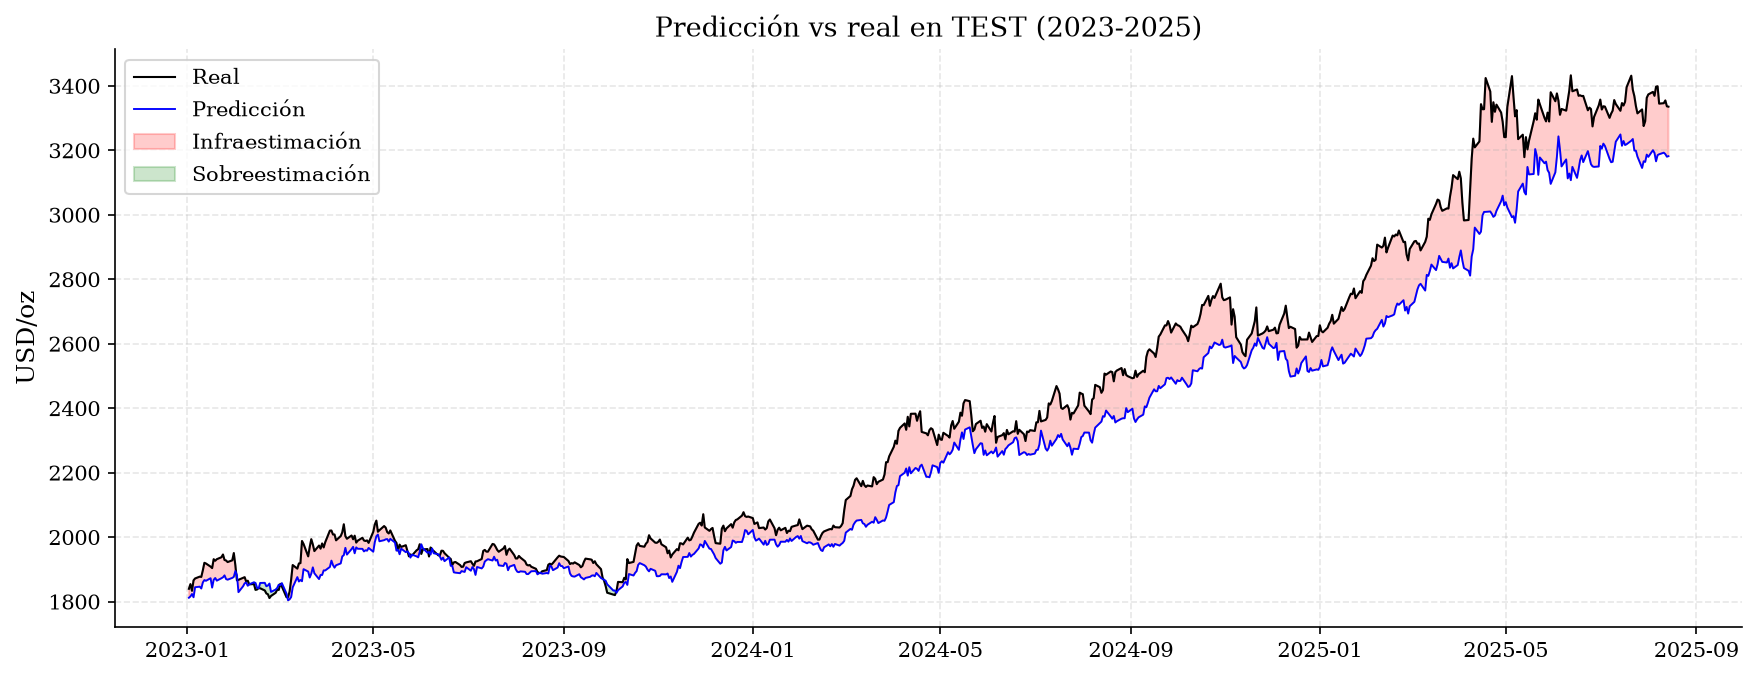

In [6]:
import matplotlib.pyplot as plt

from src.utils import save_fig

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(te["date"], y_te, "k-", lw=1, label="Real")
ax.plot(te["date"], y_pred, "b-", lw=0.9, label="Predicción")
ax.fill_between(te["date"], y_te, y_pred, where=y_pred < y_te,
                color="red", alpha=0.2, label="Infraestimación")
ax.fill_between(te["date"], y_te, y_pred, where=y_pred >= y_te,
                color="green", alpha=0.2, label="Sobreestimación")
ax.set_title("Predicción vs real en TEST (2023-2025)")
ax.set_ylabel("USD/oz")
ax.legend()
save_fig(fig, "test_predictions.png")

Análisis de residuos en test.

Histograma de residuos y evolución temporal. Los residuos crecen en
magnitud hacia 2024-2025 (régimen de alta volatilidad), lo que anticipa
la necesidad de monitorización (fase 23).

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\test_residuals.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/test_residuals.png')

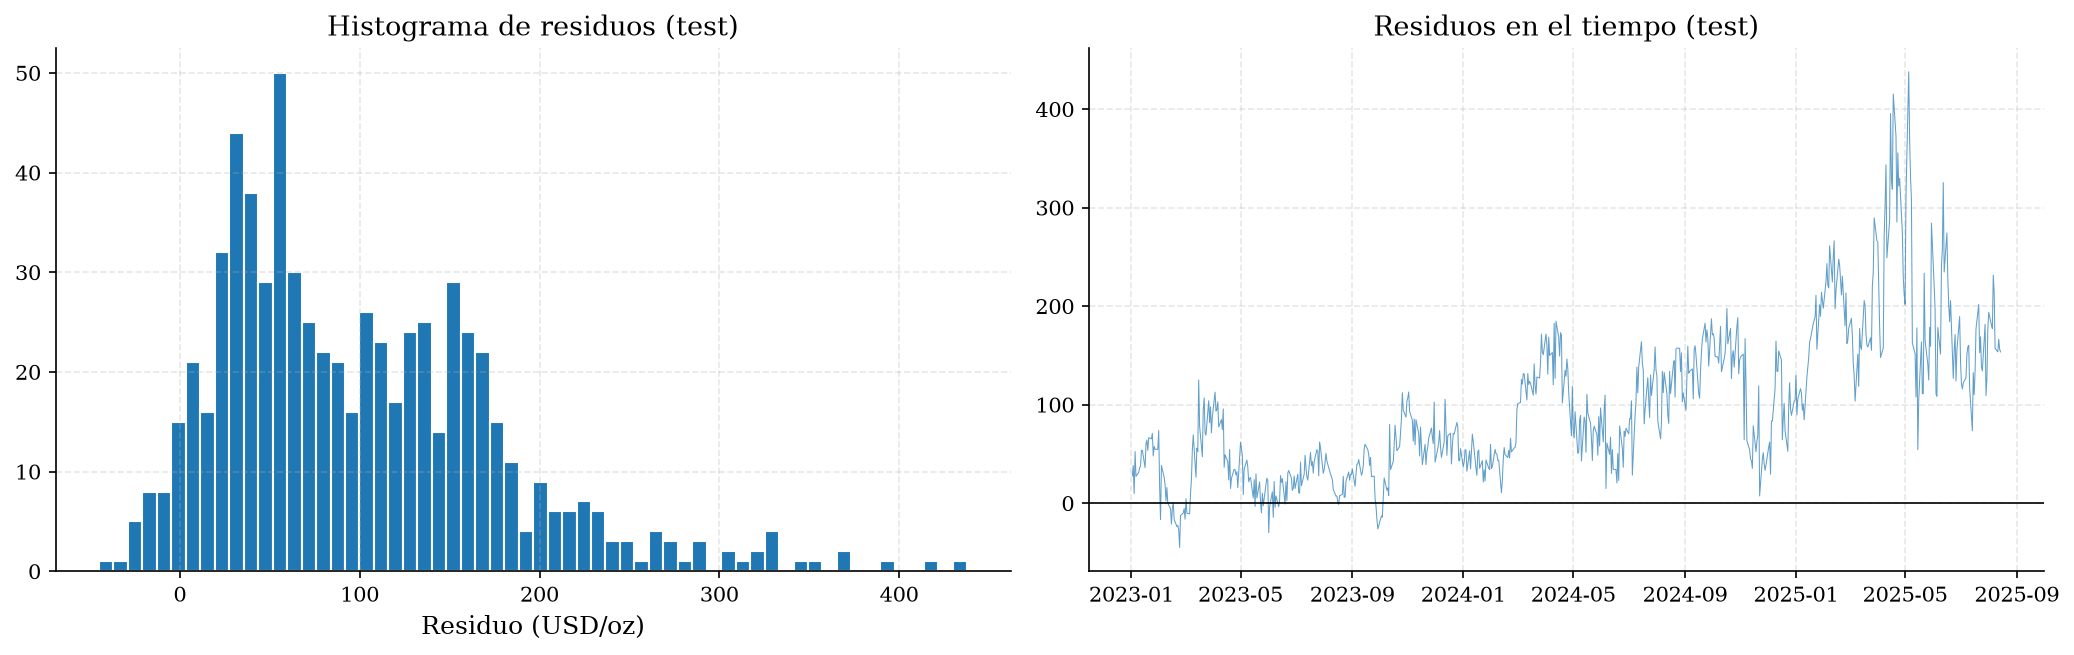

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
resid = y_te - y_pred
axes[0].hist(resid, bins=60, edgecolor="white")
axes[0].set_title("Histograma de residuos (test)")
axes[0].set_xlabel("Residuo (USD/oz)")
axes[1].plot(te["date"], resid, lw=0.5, alpha=0.7)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Residuos en el tiempo (test)")
fig.tight_layout()
save_fig(fig, "test_residuals.png")